In [1]:
import os, time, pickle
import numpy as np, torch

os.environ["OMP_NUM_THREADS"] = "4"
torch.set_num_threads(4)
DEVICE = "cpu"
torch.manual_seed(1234); np.random.seed(1234)

ROOT = os.path.abspath(".")                   
CKPT = os.path.join(ROOT, "checkpoints_xai")
OUT  = os.path.join(ROOT, "outputs", "xai2d")
for d in (CKPT, OUT, "runs", "figs"): os.makedirs(d, exist_ok=True)

def save_pickle(o,n):
    with open(os.path.join(CKPT,n),"wb") as f: pickle.dump(o,f); print("  saved",n)
def load_pickle(n):
    with open(os.path.join(CKPT,n),"rb") as f: return pickle.load(f)
def exists(n): return os.path.exists(os.path.join(CKPT,n))
def stamp(m): print(f"[{time.strftime('%H:%M:%S')}] {m}")

In [2]:
import burgers2d_common as B
import train2d, train2d_q, qpinn2d
from xai.adapter import ModelAdapter
from xai import report, layer2, layer3, domain, scaling, utils
from xai.xai_adapter_2d import make_probe       
import xai
import torch.nn as nn


class PINN2D(nn.Module):
    """Fully-connected PINN: (x, y, t) -> (u, v).

    Stores the last hidden-layer activations when `capture=True`,
    used later for the interpretability figure.
    """

    def __init__(self, width=64, depth=5, in_dim=3, out_dim=2):
        super().__init__()
        layers, d = [], in_dim
        for _ in range(depth):
            layers += [nn.Linear(d, width), nn.Tanh()]
            d = width
        layers += [nn.Linear(d, out_dim)]
        self.net = nn.Sequential(*layers)
        self.width, self.depth = width, depth
        self.capture = False
        self._last_hidden = None
        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, z):
        if not self.capture:
            return self.net(z)
        h = z
        for layer in self.net[:-1]:
            h = layer(h)
        self._last_hidden = h.detach()
        return self.net[-1](h)

    @torch.no_grad()
    def hidden_at(self, z):
        """Return last-hidden-layer activations for input batch z."""
        prev, self.capture = self.capture, True
        _ = self.forward(z)
        self.capture = prev
        return self._last_hidden
print("  ok: repo modules + xai", xai.__version__, "+ adapter bridge")
print("  NU_DEFAULT =", B.NU_DEFAULT)

  ok: repo modules + xai 1.0.0 + adapter bridge
  NU_DEFAULT = 0.01


In [3]:
nu = B.NU_DEFAULT
def exact_residual_max(n=64):
    h=dt=1e-4
    x=torch.rand(n,1)*0.8+0.1; y=torch.rand(n,1)*0.8+0.1; t=torch.rand(n,1)*0.8+0.1
    U=lambda a,b,c: B.exact_uv(a,b,c,nu); u,v=U(x,y,t)
    ux=(U(x+h,y,t)[0]-U(x-h,y,t)[0])/(2*h); uy=(U(x,y+h,t)[0]-U(x,y-h,t)[0])/(2*h)
    ut=(U(x,y,t+dt)[0]-U(x,y,t-dt)[0])/(2*dt)
    uxx=(U(x+h,y,t)[0]-2*u+U(x-h,y,t)[0])/h**2; uyy=(U(x,y+h,t)[0]-2*u+U(x,y-h,t)[0])/h**2
    return (ut+u*ux+v*uy-nu*(uxx+uyy)).abs().max().item()
print("  max |r_u| on analytic solution:", f"{exact_residual_max():.3e}")

def gt_field(P, field="u"):
    x=torch.tensor(P[:,0:1],dtype=torch.float32); y=torch.tensor(P[:,1:2],dtype=torch.float32)
    t=torch.tensor(P[:,2:3],dtype=torch.float32)
    u,v=B.exact_uv(x,y,t,nu)
    return (u if field=="u" else v).detach().cpu().numpy().ravel()

  max |r_u| on analytic solution: 2.366e-01


In [4]:
# train classical PINN2D on CPU

PINN_PT, PINN_HIST = "pinn2d.pt", "pinn2d_hist.pkl"
PINN_CFG = dict(iters=2000, n_r=3000, n_i=500, n_b=250,
                lam_r=1.0, lam_i=10.0, lam_b=10.0,
                lr=1e-3, resample_every=2000, seed=1234)

if exists(PINN_PT) and exists(PINN_HIST):
    stamp("loading PINN2D")
    pinn = PINN2D(width=64, depth=5).to(DEVICE)
    pinn.load_state_dict(torch.load(os.path.join(CKPT,PINN_PT), map_location=DEVICE)); pinn.eval()
    hist_pinn = load_pickle(PINN_HIST)
else:
    stamp("training PINN2D (CPU)")
    pinn = PINN2D(width=64, depth=5).to(DEVICE); t0=time.perf_counter()
    hist_pinn, _ = train2d.train_pinn2d(pinn, device=DEVICE, tag="pinn2d_xai",
                    extra_meta={"model":"PINN2D"}, **PINN_CFG)
    pinn = train2d.lbfgs_polish(pinn, iters=0, device=DEVICE, seed=1234)
    stamp(f"PINN2D wall = {time.perf_counter()-t0:.1f}s")
    torch.save(pinn.state_dict(), os.path.join(CKPT,PINN_PT)); save_pickle(hist_pinn, PINN_HIST)

ru,rv = train2d._val_errors(pinn, nu, DEVICE)
print(f"  PINN2D rel_u={ru:.3e} rel_v={rv:.3e}")
save_pickle({"rel_u":ru,"rel_v":rv}, "pinn2d_eval.pkl")
stamp("Cell 3 done")

[19:15:52] loading PINN2D
  PINN2D rel_u=5.829e-03 rel_v=6.954e-03
  saved pinn2d_eval.pkl
[19:15:52] Cell 3 done


In [5]:
QP_PT, QP_HIST, QP_SNAP = "qpinn2d.pt", "qpinn2d_hist.pkl", "qpinn2d_snaps.pkl"
QP_CFG   = dict(n_qubits=3, n_layers=2, enc_width=16, head_width=16, reupload=False)
QP_ITERS = 2000
SNAP_EVERY = 500                   

if exists(QP_PT) and exists(QP_HIST) and exists(QP_SNAP):
    stamp("loading QPINN2D")
    qpinn = qpinn2d.QPINN2D(**QP_CFG).to(DEVICE)
    qpinn.load_state_dict(torch.load(os.path.join(CKPT,QP_PT), map_location=DEVICE)); qpinn.eval()
    hist_qpinn = load_pickle(QP_HIST); q_snaps = load_pickle(QP_SNAP)
else:
    stamp("training QPINN2D (single continuous run — slowest cell)")
    qpinn = qpinn2d.QPINN2D(**QP_CFG)

    q_snaps = {}
    def snap_cb(it, model):
        q_snaps[it] = model.q_weights.detach().cpu().numpy().copy()

    t0 = time.perf_counter()
    hist_qpinn, _ = train2d_q.train_qapinn2d(
        qpinn, iters=QP_ITERS, n_r=256, n_i=128, n_b=32,
        lam_r=1.0, lam_i=10.0, lam_b=10.0, lr=3e-3, device=DEVICE,
        log_every=50, val_every=250, tag="qpinn2d_xai", seed=1234, chunk=256,
        snapshot_every=SNAP_EVERY, snapshot_cb=snap_cb,
        return_best=True,               # keep best-val weights, not last
        extra_meta={"model":"QPINN2D", **QP_CFG})
    stamp(f"QPINN2D wall = {time.perf_counter()-t0:.1f}s")

    torch.save(qpinn.state_dict(), os.path.join(CKPT,QP_PT))
    save_pickle(hist_qpinn, QP_HIST); save_pickle(q_snaps, QP_SNAP)

ru,rv = train2d._val_errors(qpinn, nu, DEVICE)
print(f"  QPINN2D rel_u={ru:.3e} rel_v={rv:.3e}   snapshots: {sorted(q_snaps)}")
save_pickle({"rel_u":ru,"rel_v":rv}, "qpinn2d_eval.pkl")
stamp("Cell 4 done")

[19:16:58] training QPINN2D (single continuous run — slowest cell)
    0  L=2.794e+01  relL2 u=2.783e-01 v=1.096e+00 | 2s
  250  L=6.229e-03  relL2 u=1.775e-02 v=1.544e-02 | 86s
  500  L=2.013e-03  relL2 u=8.566e-03 v=8.349e-03 | 176s
  750  L=1.269e-03  relL2 u=6.308e-03 v=6.644e-03 | 257s
 1000  L=7.577e-04  relL2 u=4.343e-03 v=5.309e-03 | 334s
 1250  L=4.615e-04  relL2 u=3.067e-03 v=4.284e-03 | 416s
 1500  L=3.347e-04  relL2 u=2.595e-03 v=3.677e-03 | 495s
 1750  L=2.895e-04  relL2 u=2.470e-03 v=3.408e-03 | 576s
 2000  L=2.733e-04  relL2 u=2.432e-03 v=3.301e-03 | 654s
[return_best] reloaded best.pt from it=2000 (rel_u=2.432e-03 rel_v=3.301e-03)
[19:27:55] QPINN2D wall = 656.9s
  saved qpinn2d_hist.pkl
  saved qpinn2d_snaps.pkl
  QPINN2D rel_u=2.396e-03 rel_v=3.285e-03   snapshots: [0, 500, 1000, 1500, 2000]
  saved qpinn2d_eval.pkl
[19:27:55] Cell 4 done


In [6]:
# adapters through the 2D bridge; history remap for Layer 3
BOUNDS = [(0.0,1.0), (0.0,1.0), (0.0,1.0)]        # (x,y,t)
probe_u = make_probe(qpinn, field="u", device=DEVICE)
def field_adapter(model, field, name):
    idx = 0 if field=="u" else 1
    return ModelAdapter(lambda Z: model(Z)[:, idx:idx+1],
                        parameters=list(model.parameters()),
                        device=DEVICE, name=name, d_in=3)
classical_u = field_adapter(pinn, "u", "pinn2d_u")

print("  probe forward", tuple(probe_u(torch.rand(4,3)).shape),
      "| probs", tuple(probe_u.probs(torch.rand(4,3)).shape),
      "| has_state", probe_u.has_state())

def remap_hist(h):
    t = h["train"]
    return {"total": np.asarray(t["loss"]), "iter": np.asarray(t["it"]),
            "wall": np.asarray(t["wall"]),
            "pde": np.asarray(t.get("L_r", t["loss"])),
            "ic":  np.asarray(t.get("L_ic", t["loss"])),
            "bc":  np.asarray(t.get("L_bc", t["loss"]))}
H_pinn, H_qpinn = remap_hist(hist_pinn), remap_hist(hist_qpinn)
stamp("Cell 5 done — adapters + remapped histories ready")

  probe forward (4, 1) | probs (4, 8) | has_state True
[19:32:34] Cell 5 done — adapters + remapped histories ready


In [7]:
# ============================================================================
# CELL 6 — Layer-3 loss closures and Layer-2 residual (via B.pde_residual)
# ============================================================================
torch.manual_seed(7)
Xr_=torch.rand(1200,1); Yr_=torch.rand(1200,1); Tr_=torch.rand(1200,1)
Xi_=torch.rand(256,1);  Yi_=torch.rand(256,1)

def total_loss(model):
    # B.pde_residual clones+sets requires_grad internally; pass fresh clones
    ru,rv = B.pde_residual(model, Xr_.clone(), Yr_.clone(), Tr_.clone())
    l_r = (ru**2).mean() + (rv**2).mean()
    p0  = model(torch.cat([Xi_, Yi_, torch.zeros_like(Xi_)],1))
    u0,v0 = B.exact_uv(Xi_, Yi_, torch.zeros_like(Xi_))
    l_i = ((p0[:,0:1]-u0)**2).mean() + ((p0[:,1:2]-v0)**2).mean()
    return l_r + 10.0*l_i

loss_q = lambda: total_loss(qpinn)
loss_c = lambda: total_loss(pinn)

def residual_fn_u(adapter, X):
    model = qpinn if "qpinn" in adapter.name else pinn
    ru,rv = B.pde_residual(model, X[:,0:1].clone(), X[:,1:2].clone(), X[:,2:3].clone())
    return ru.detach().cpu().numpy().ravel()

print("  loss_q =", float(loss_q().detach()), " loss_c =", float(loss_c().detach()))
stamp("Cell 6 done")

  loss_q = 0.0002122935256920755  loss_c = 0.0012300926027819514
[19:32:57] Cell 6 done


In [8]:
# ============================================================================
# CELL 7 — LAYER 2: quantum-layer explainability (u field)
# ============================================================================
L2 = {}
stamp("2.1 input sensitivity");        L2["2.1"]  = layer2.input_sensitivity(probe_u, BOUNDS, n=1000, outdir=OUT)
stamp("2.2 measurement operators");    L2["2.2"]  = layer2.measurement_operators(probe_u, BOUNDS, residual_fn=residual_fn_u, n=500, outdir=OUT)
stamp("2.4 entanglement");             L2["2.4"]  = layer2.entanglement_analysis(probe_u, BOUNDS, residual_fn=residual_fn_u, n=300, outdir=OUT)
stamp("2.5 fourier (x-axis)");         L2["2.5"]  = layer2.fourier_spectrum(probe_u, BOUNDS, axis=0, classical_ref=classical_u, outdir=OUT)
stamp("2.6 expressivity");             L2["2.6"]  = layer2.expressivity_analysis(probe_u, BOUNDS, n_states=300, outdir=OUT)
stamp("2.9 measurement distribution"); L2["2.9"]  = layer2.measurement_distribution(probe_u, BOUNDS, n=500, outdir=OUT)
stamp("2.10 saliency (quantum)");      L2["2.10q"]= layer2.feature_attribution(probe_u, BOUNDS, axes=(0,1), outdir=OUT)
stamp("2.10 saliency (classical)");    L2["2.10c"]= layer2.feature_attribution(classical_u, BOUNDS, axes=(0,1), outdir=OUT)
stamp("2.8 loss landscape");           L2["2.8"]  = layer2.loss_landscape(probe_u, lambda: float(loss_q().detach()), span=1.0, n=15, outdir=OUT)

print(f"\n  Meyer–Wallach Q     = {L2['2.4']['meyer_wallach_Q']:.3f}")
print(f"  spectral centroid   = {L2['2.5']['spectral_centroid']:.2f}  reachable f ≤ {L2['2.5']['theoretical_reachable_freq']}")
print(f"  effective dimension = {L2['2.6']['effective_dimension']:.1f} / {L2['2.6']['feature_dim']}")
print(f"  measurement entropy = {L2['2.9']['mean_entropy']:.2f} bits")
save_pickle(L2, "layer2_results.pkl")
stamp("Cell 7 done")

[19:33:08] 2.1 input sensitivity
[19:33:09] 2.2 measurement operators
[19:33:09] 2.4 entanglement
[19:33:11] 2.5 fourier (x-axis)
[19:33:12] 2.6 expressivity
[19:33:13] 2.9 measurement distribution
[19:33:13] 2.10 saliency (quantum)
[19:33:14] 2.10 saliency (classical)
[19:33:14] 2.8 loss landscape

  Meyer–Wallach Q     = 0.087
  spectral centroid   = 43.04  reachable f ≤ 1
  effective dimension = 2.3 / 8
  measurement entropy = 0.86 bits
  saved layer2_results.pkl
[19:33:56] Cell 7 done


In [9]:
# ============================================================================
# CELL 8 — LAYER 3: optimisation geometry
# ============================================================================
L3 = {}
stamp("Layer 3 — QPINN2D"); L3["qa"] = layer3.optimization_report(probe_u, loss_q, hist=H_qpinn, outdir=OUT)
stamp("Layer 3 — PINN2D");  L3["cl"] = layer3.optimization_report(classical_u, loss_c, hist=H_pinn, outdir=OUT)
for tag,r in (("QPINN2D",L3["qa"]),("PINN2D",L3["cl"])):
    h=r.get("hessian")
    print(f"\n  {tag}: grad-norm {r['gradient'].get('grad_norm_mean',float('nan')):.3e}")
    if h: print(f"    λmax {h['lambda_max']:.3e}  cond {h['condition_number']:.2e}  lr-ceiling {h['lr_ceiling']:.2e}")
save_pickle(L3, "layer3_results.pkl")
stamp("Cell 8 done")

[19:33:58] Layer 3 — QPINN2D
[19:35:57] Layer 3 — PINN2D

  QPINN2D: grad-norm 2.942e-02
    λmax 2.710e+02  cond 1.53e+04  lr-ceiling 7.38e-03

  PINN2D: grad-norm 7.769e-02
    λmax 4.691e+02  cond 3.42e+05  lr-ceiling 4.26e-03
  saved layer3_results.pkl
[19:36:15] Cell 8 done


In [10]:
# ============================================================================
# CELL 9 — LAYER 2.11: quantum-state evolution across training segments
# ============================================================================
def make_probe_from_weights(w):
    m = qpinn2d.QPINN2D(**QP_CFG).to(DEVICE)
    # copy trained encoder/head so the encoded inputs match; only q_weights vary
    m.load_state_dict(qpinn.state_dict())
    with torch.no_grad(): m.q_weights.copy_(torch.tensor(w))
    return make_probe(m, field="u", name="snap")

stamp("2.11 quantum-state evolution")
evo = layer2.quantum_state_evolution(make_probe_from_weights, q_snaps, BOUNDS,
                                     outdir=OUT, name="qpinn2d")
print("  snapshot->snapshot fidelity:", [round(f,3) for f in evo["fidelity"]])
save_pickle(evo, "layer2_11_evolution.pkl")
stamp("Cell 9 done")

[20:26:41] 2.11 quantum-state evolution
  snapshot->snapshot fidelity: [1.0, 0.987, 0.998, 1.0, 1.0]
  saved layer2_11_evolution.pkl
[20:26:42] Cell 9 done


In [12]:
# ============================================================================
# CELL 10 — LAYER 2.7: barren-plateau scan (fresh random QPINN2Ds)
# ============================================================================
def make_fresh(nq, depth):
    m = qpinn2d.QPINN2D(n_qubits=nq, n_layers=depth, enc_width=16,
                        head_width=16, reupload=True).to(DEVICE)
    return make_probe(m, field="u", name=f"{nq}q")

stamp("2.7 barren-plateau scan (CPU: qubits ≤ 6)")
bp = layer2.barren_plateau_analysis(make_fresh, BOUNDS,
        qubit_list=(2,4,6), depth_list=(2,4,8),
        n_samples=25, n_points=48, outdir=OUT, name="qpinn2d")
save_pickle(bp, "layer2_7_barren.pkl")
stamp("Cell 10 done")

[20:27:41] 2.7 barren-plateau scan (CPU: qubits ≤ 6)
  saved layer2_7_barren.pkl
[20:27:57] Cell 10 done


In [13]:
# ============================================================================
# CELL 11 — QUBIT SCALING (short trainings via train2d_q, cached)
# ============================================================================
def build_probe_and_metrics(nq):
    tag=f"scale2d_{nq}q.pt"; htag=f"scale2d_{nq}q_hist.pkl"
    m = qpinn2d.QPINN2D(n_qubits=nq, n_layers=3, enc_width=32, head_width=32, reupload=True)
    if exists(tag):
        m.load_state_dict(torch.load(os.path.join(CKPT,tag), map_location=DEVICE)); h=load_pickle(htag)
    else:
        stamp(f"  training scaling nq={nq}")
        h,_ = train2d_q.train_qapinn2d(m, iters=1200, n_r=256, n_i=128, n_b=32,
                lam_r=1.0, lam_i=10.0, lam_b=10.0, lr=3e-3, device=DEVICE,
                log_every=100, val_every=400, tag=f"scale2d_{nq}q", seed=1234, chunk=256)
        torch.save(m.state_dict(), os.path.join(CKPT,tag)); save_pickle(h, htag)
    ru,rv = train2d._val_errors(m, nu, DEVICE)
    return make_probe(m, field="u", name=f"{nq}q"), dict(rel_l2=float(ru))

stamp("qubit-scaling {2,4,6}")
sc = scaling.qubit_scaling(build_probe_and_metrics, BOUNDS, qubit_list=(2,4,6),
                           n_eval=250, outdir=OUT, name="qpinn2d")
save_pickle(sc, "scaling_results.pkl")
for row in sc["table"]:
    print(f"  {row['n_qubits']}q: rel-L2 {row.get('rel_l2',float('nan')):.3e} "
          f"eff-dim {row.get('effective_dimension',float('nan')):.1f} "
          f"Q {row.get('meyer_wallach_Q',float('nan')):.2f} "
          f"H {row.get('measurement_entropy',float('nan')):.2f}")
stamp("Cell 11 done")

[20:35:55] qubit-scaling {2,4,6}
[20:35:55]   training scaling nq=2
    0  L=1.872e+01  relL2 u=7.415e-01 v=7.663e-01 | 0s
  400  L=1.599e-02  relL2 u=3.422e-02 v=2.312e-02 | 127s
  800  L=3.827e-03  relL2 u=1.598e-02 v=1.026e-02 | 307s
 1200  L=2.517e-03  relL2 u=1.246e-02 v=7.878e-03 | 485s
  saved scale2d_2q_hist.pkl
[20:44:01]   training scaling nq=4
    0  L=2.587e+01  relL2 u=8.995e-01 v=8.147e-01 | 1s
  400  L=6.700e-03  relL2 u=2.082e-02 v=1.326e-02 | 446s
  800  L=1.651e-03  relL2 u=8.221e-03 v=6.221e-03 | 879s
 1200  L=1.418e-03  relL2 u=7.426e-03 v=5.731e-03 | 1263s
  saved scale2d_4q_hist.pkl
[21:05:04]   training scaling nq=6
    0  L=2.453e+01  relL2 u=9.156e-01 v=9.395e-01 | 3s
  400  L=2.792e-03  relL2 u=1.232e-02 v=7.183e-03 | 1015s
  800  L=1.223e-03  relL2 u=8.041e-03 v=4.355e-03 | 2105s
 1200  L=9.966e-04  relL2 u=7.172e-03 v=3.826e-03 | 3262s
  saved scale2d_6q_hist.pkl
  saved scaling_results.pkl
  2q: rel-L2 1.246e-02 eff-dim 1.3 Q 0.23 H 1.38
  4q: rel-L2 7.413e

In [14]:
# ============================================================================
# CELL 12 — LAYER 4: time extrapolation vs the exact solution
# ============================================================================
# exact_uv is valid for any t, so no re-solve needed — clean advantage here.
ref_u = lambda P: gt_field(P, "u")
stamp("Layer 4 — domain generalisation (u field)")
dg = domain.domain_generalization({"qpinn2d":probe_u, "pinn2d":classical_u},
        ref_u, BOUNDS, extend_axis=2, factors=(1.0,1.5,2.0,3.0), n=4000, outdir=OUT)
for name,errs in dg["rel_l2"].items():
    print(f"  {name}: " + "  ".join(f"{f}×={e:.2e}" for f,e in zip(dg["factors"],errs)))
save_pickle(dg, "layer4_domain.pkl")
stamp("Cell 12 done")

[22:01:48] Layer 4 — domain generalisation (u field)
  qpinn2d: 1.0×=2.29e-03  1.5×=4.01e-03  2.0×=1.01e-02  3.0×=3.81e-02
  pinn2d: 1.0×=5.60e-03  1.5×=6.27e-03  2.0×=8.38e-03  3.0×=1.48e-02
  saved layer4_domain.pkl
[22:01:48] Cell 12 done


In [15]:
# CELL 13 — bundle everything into one manifest
rep = report.XAIReport(probe_u, BOUNDS, classical=classical_u,
                       residual_fn=residual_fn_u, outdir=OUT, tag="burgers2d_4q_cpu")
rep.results["layer2"] = load_pickle("layer2_results.pkl")
rep.results["layer2"]["2.7_barren_plateau"] = load_pickle("layer2_7_barren.pkl")
rep.results["layer2"]["2.11_state_evolution"] = load_pickle("layer2_11_evolution.pkl")
rep.results["layer3"] = load_pickle("layer3_results.pkl")
rep.results["layer4"] = {"domain_generalization": load_pickle("layer4_domain.pkl")}
rep.results["qubit_scaling"] = load_pickle("scaling_results.pkl")
rep.results["performance"] = {"pinn2d":load_pickle("pinn2d_eval.pkl"),
                              "qpinn2d":load_pickle("qpinn2d_eval.pkl")}
path = rep.save_manifest()
print("\n  manifest:", path, "\n  figures:", OUT, "\n  checkpoints:", CKPT)
c=rep.results["performance"]["pinn2d"]["rel_u"]; q=rep.results["performance"]["qpinn2d"]["rel_u"]
print(f"\n  === HEADLINE (u field) ===\n  PINN2D  rel-L2 = {c:.4e}\n  QPINN2D rel-L2 = {q:.4e}")
print(f"  ratio = {q/c:.2f}× ({'QPINN better' if q<c else 'classical better'})")
stamp("Cell 13 done — FULL 2D XAI REPORT COMPLETE")


  manifest: d:\PINN\Burgers_2d\outputs\xai2d\manifest_burgers2d_4q_cpu.json 
  figures: d:\PINN\Burgers_2d\outputs\xai2d 
  checkpoints: d:\PINN\Burgers_2d\checkpoints_xai

  === HEADLINE (u field) ===
  PINN2D  rel-L2 = 5.8290e-03
  QPINN2D rel-L2 = 2.3957e-03
  ratio = 0.41× (QPINN better)
[22:01:51] Cell 13 done — FULL 2D XAI REPORT COMPLETE



                    TABLE 1 — HEADLINE: PINN2D vs QPINN2D                     
                         PINN2D (classical)               QPINN2D (quantum)
architecture        MLP (width 64, depth 5)  enc→PQC(3q×2L,reup=False)→head
total parameters                      17026                             775
  ├ encoder params                      NaN                             387
  ├ quantum params                        —                              18
  └ head params                         NaN                             370
rel-L2 (u)                         0.005829                        0.002396
rel-L2 (v)                         0.006954                        0.003285
rel-L2 (mean)                      0.006392                         0.00284
training iters                         2000                            2000
wall-clock (s)                        264.9                           653.5
ms / iter                            132.43                          326.74

  accur

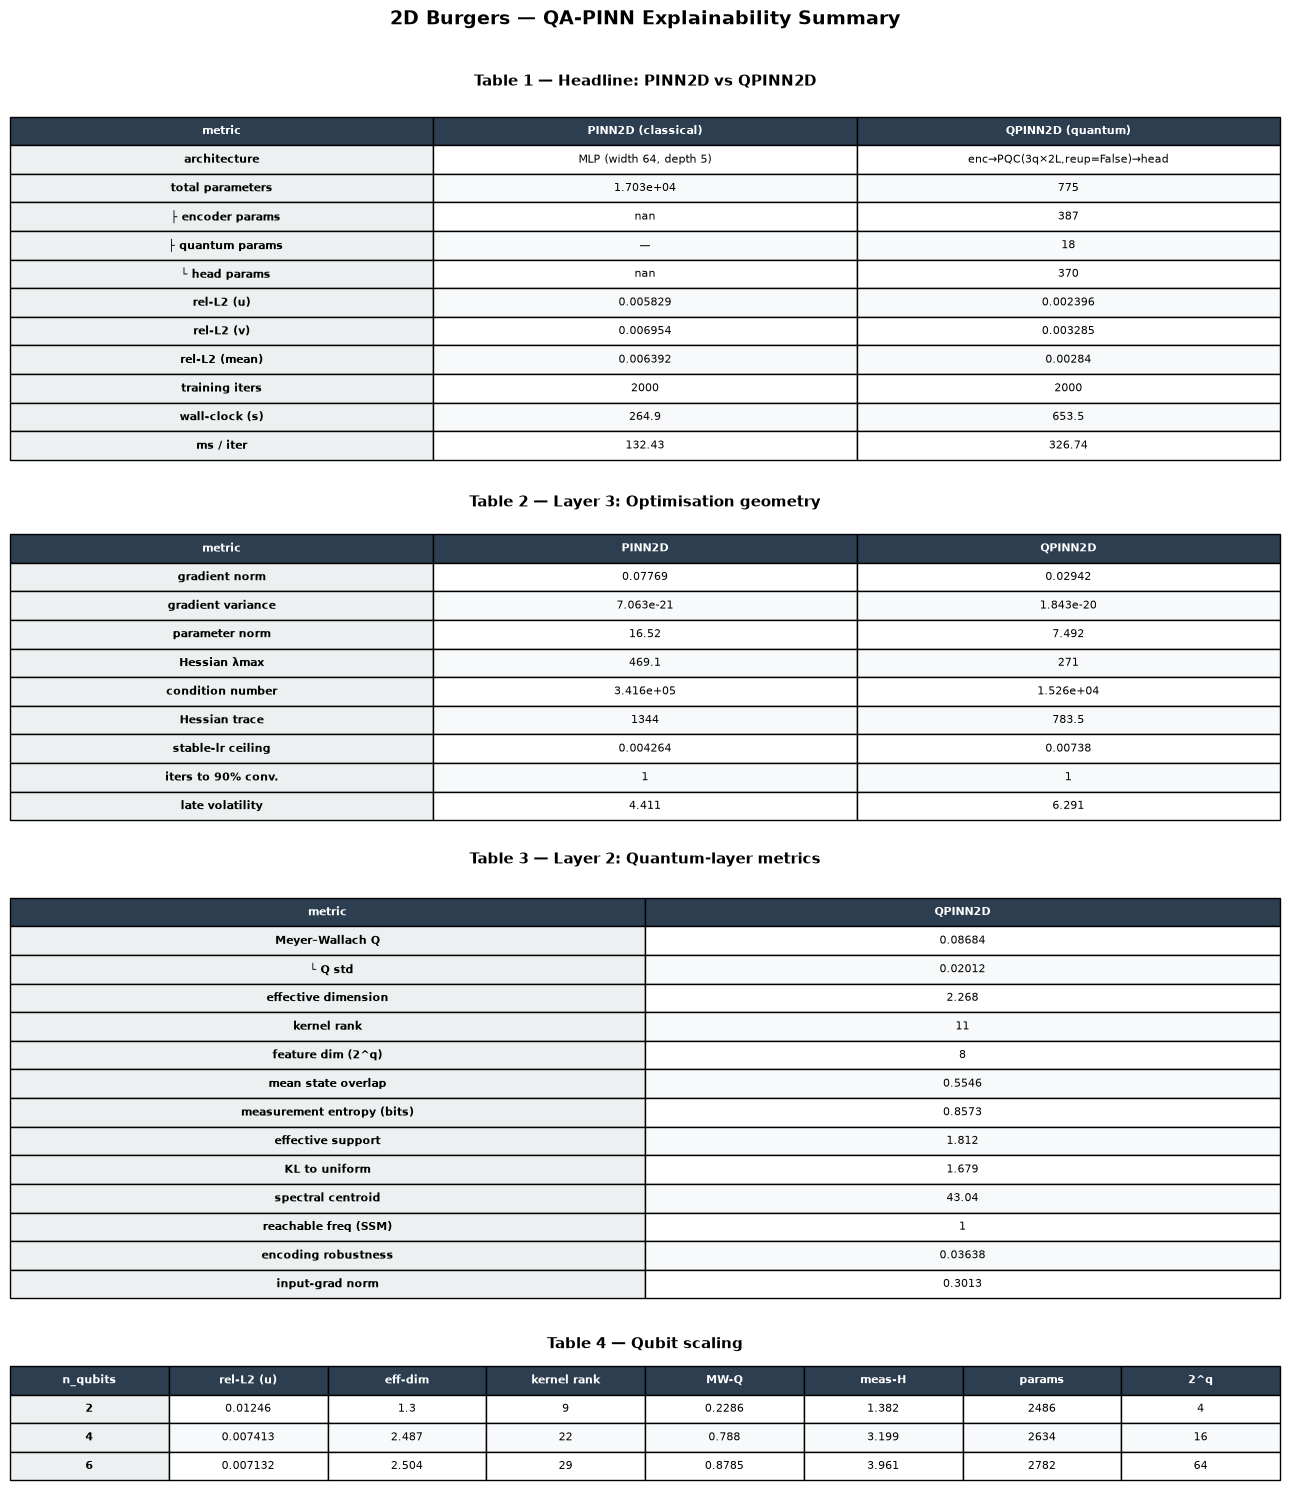


  CSVs + PNG saved to: d:\PINN\Burgers_2d\outputs\xai2d\tables
[22:12:49] Cell 14 done — results tables complete


In [16]:
# ============================================================================
# CELL 14 — FINAL RESULTS TABLES (PINN2D vs QPINN2D)
# ============================================================================
# Pulls everything from checkpoints_xai/ into clean comparison tables:
#   Table 1 — headline: architecture, parameters, accuracy, cost
#   Table 2 — Layer-3 optimisation geometry (both models)
#   Table 3 — Layer-2 quantum-layer metrics (QPINN only)
#   Table 4 — qubit-scaling sweep
# Saves CSVs + a rendered PNG. Safe to run in a fresh kernel (reads from disk).

import pandas as pd
import numpy as np, torch, os
import qpinn2d, burgers2d_common as B

pd.set_option("display.float_format", lambda v: f"{v:.4g}")

def _get(d, *keys, default=np.nan):
    """Safe nested lookup."""
    for k in keys:
        if not isinstance(d, dict) or k not in d: return default
        d = d[k]
    return d

# ---- load everything from checkpoints -------------------------------------
L2   = load_pickle("layer2_results.pkl")
L3   = load_pickle("layer3_results.pkl")
scl  = load_pickle("scaling_results.pkl")
perf_c = load_pickle("pinn2d_eval.pkl")      # {'rel_u','rel_v'}
perf_q = load_pickle("qpinn2d_eval.pkl")

# param breakdown straight from the live models
def param_breakdown(model, quantum=False):
    enc = sum(p.numel() for p in model.encoder.parameters()) if hasattr(model,"encoder") else np.nan
    head= sum(p.numel() for p in model.head.parameters())    if hasattr(model,"head")    else np.nan
    qw  = int(model.q_weights.numel()) if quantum else 0
    tot = sum(p.numel() for p in model.parameters())
    return enc, qw, head, tot

enc_c, qw_c, head_c, tot_c = param_breakdown(pinn,  quantum=False)
enc_q, qw_q, head_q, tot_q = param_breakdown(qpinn, quantum=True)

# wall-clock (final entry of each history)
wall_c = float(np.asarray(hist_pinn["train"]["wall"])[-1])  if "train" in hist_pinn else np.nan
wall_q = float(np.asarray(hist_qpinn["train"]["wall"])[-1]) if "train" in hist_qpinn else np.nan
iters_c = int(np.asarray(hist_pinn["train"]["it"])[-1])  if "train" in hist_pinn else np.nan
iters_q = int(np.asarray(hist_qpinn["train"]["it"])[-1]) if "train" in hist_qpinn else np.nan

# ======================================================================
# TABLE 1 — headline comparison
# ======================================================================
mean_c = 0.5*(perf_c["rel_u"] + perf_c["rel_v"])
mean_q = 0.5*(perf_q["rel_u"] + perf_q["rel_v"])
t1 = pd.DataFrame({
    "PINN2D (classical)": [
        "MLP (width 64, depth 5)", tot_c, enc_c, "—", head_c,
        perf_c["rel_u"], perf_c["rel_v"], mean_c,
        iters_c, f"{wall_c:.1f}", f"{wall_c/max(iters_c,1)*1e3:.2f}"],
    "QPINN2D (quantum)": [
        f"enc→PQC({qpinn.n_qubits}q×{qpinn.n_layers}L,reup={qpinn.reupload})→head",
        tot_q, enc_q, qw_q, head_q,
        perf_q["rel_u"], perf_q["rel_v"], mean_q,
        iters_q, f"{wall_q:.1f}", f"{wall_q/max(iters_q,1)*1e3:.2f}"],
}, index=[
    "architecture", "total parameters", "  ├ encoder params",
    "  ├ quantum params", "  └ head params",
    "rel-L2 (u)", "rel-L2 (v)", "rel-L2 (mean)",
    "training iters", "wall-clock (s)", "ms / iter"])

# ======================================================================
# TABLE 2 — Layer-3 optimisation geometry
# ======================================================================
def l3row(r):
    g, h = r.get("gradient", {}), (r.get("hessian") or {})
    s = r.get("stability") or {}
    return [g.get("grad_norm_mean", np.nan), g.get("grad_variance", np.nan),
            g.get("param_norm", np.nan), h.get("lambda_max", np.nan),
            h.get("condition_number", np.nan), h.get("hessian_trace", np.nan),
            h.get("lr_ceiling", np.nan), s.get("iters_to_90pct", np.nan),
            s.get("late_volatility", np.nan)]
t2 = pd.DataFrame({"PINN2D": l3row(L3["cl"]), "QPINN2D": l3row(L3["qa"])},
    index=["gradient norm", "gradient variance", "parameter norm",
           "Hessian λmax", "condition number", "Hessian trace",
           "stable-lr ceiling", "iters to 90% conv.", "late volatility"])

# ======================================================================
# TABLE 3 — Layer-2 quantum-layer metrics (QPINN only)
# ======================================================================
ent, exp, md = L2.get("2.4", {}), L2["2.6"], L2["2.9"]
fou, isen    = L2["2.5"], L2["2.1"]
t3 = pd.DataFrame({"QPINN2D": [
    _get(ent, "meyer_wallach_Q"), _get(ent, "Q_std"),
    exp["effective_dimension"], exp["kernel_rank"], exp["feature_dim"],
    exp["mean_state_overlap"], md["mean_entropy"], md["effective_support"],
    md["kl_to_uniform"], fou["spectral_centroid"], fou["theoretical_reachable_freq"],
    isen["encoding_robustness"], isen["grad_norm_mean"],
]}, index=[
    "Meyer–Wallach Q", "  └ Q std",
    "effective dimension", "kernel rank", "feature dim (2^q)",
    "mean state overlap", "measurement entropy (bits)", "effective support",
    "KL to uniform", "spectral centroid", "reachable freq (SSM)",
    "encoding robustness", "input-grad norm"])

# ======================================================================
# TABLE 4 — qubit-scaling sweep
# ======================================================================
t4 = pd.DataFrame(scl["table"]).set_index("n_qubits")
keep = [c for c in ["rel_l2", "effective_dimension", "kernel_rank",
                    "meyer_wallach_Q", "measurement_entropy",
                    "param_count", "feature_dim"] if c in t4.columns]
t4 = t4[keep].rename(columns={
    "rel_l2":"rel-L2 (u)", "effective_dimension":"eff-dim",
    "kernel_rank":"kernel rank", "meyer_wallach_Q":"MW-Q",
    "measurement_entropy":"meas-H", "param_count":"params",
    "feature_dim":"2^q"})

# ---- print ---------------------------------------------------------------
print("\n" + "="*78)
print("TABLE 1 — HEADLINE: PINN2D vs QPINN2D".center(78)); print("="*78)
print(t1.to_string())
adv = "QPINN better" if mean_q < mean_c else "classical better"
print(f"\n  accuracy ratio (QPINN/PINN, mean rel-L2) = {mean_q/mean_c:.2f}×  → {adv}")
print(f"  parameter ratio (QPINN/PINN)             = {tot_q/tot_c:.2f}×")

print("\n" + "="*78)
print("TABLE 2 — LAYER 3: OPTIMISATION GEOMETRY".center(78)); print("="*78)
print(t2.to_string())

print("\n" + "="*78)
print("TABLE 3 — LAYER 2: QUANTUM-LAYER METRICS (QPINN2D)".center(78)); print("="*78)
print(t3.to_string())
if isinstance(_get(ent,"interpretation"), str):
    print(f"\n  entanglement verdict: {ent['interpretation']}")
print(f"  Fourier note: reachable band is encoding-determined "
      f"(re-uploading × n_layers = {fou['theoretical_reachable_freq']}); "
      f"centroid {fou['spectral_centroid']:.2f} is empirical.")

print("\n" + "="*78)
print("TABLE 4 — QUBIT SCALING".center(78)); print("="*78)
print(t4.to_string())

# ---- save CSV + combined PNG --------------------------------------------
TBL_DIR = os.path.join(OUT, "tables"); os.makedirs(TBL_DIR, exist_ok=True)
t1.to_csv(os.path.join(TBL_DIR, "table1_headline.csv"))
t2.to_csv(os.path.join(TBL_DIR, "table2_optimisation.csv"))
t3.to_csv(os.path.join(TBL_DIR, "table3_quantum_metrics.csv"))
t4.to_csv(os.path.join(TBL_DIR, "table4_qubit_scaling.csv"))

import matplotlib.pyplot as plt
def render(ax, df, title, index_label="metric"):
    ax.axis("off"); ax.set_title(title, fontweight="bold", fontsize=11, pad=8)
    disp = df.reset_index().rename(columns={"index": index_label})
    cells = [[f"{v:.4g}" if isinstance(v,(int,float,np.floating)) and not isinstance(v,bool)
              else str(v) for v in row] for row in disp.values]
    tb = ax.table(cellText=cells, colLabels=list(disp.columns),
                  cellLoc="center", loc="center")
    tb.auto_set_font_size(False); tb.set_fontsize(8); tb.scale(1, 1.35)
    for (r,c),cell in tb.get_celld().items():
        if r==0: cell.set_facecolor("#2c3e50"); cell.set_text_props(color="w", fontweight="bold")
        elif c==0: cell.set_facecolor("#ecf0f1"); cell.set_text_props(fontweight="bold")
        elif r%2==0: cell.set_facecolor("#f7f9fa")

fig = plt.figure(figsize=(13, 15))
gs = fig.add_gridspec(4, 1, height_ratios=[len(t1)+1, len(t2)+1, len(t3)+1, len(t4)+1])
render(fig.add_subplot(gs[0]), t1, "Table 1 — Headline: PINN2D vs QPINN2D")
render(fig.add_subplot(gs[1]), t2, "Table 2 — Layer 3: Optimisation geometry")
render(fig.add_subplot(gs[2]), t3, "Table 3 — Layer 2: Quantum-layer metrics")
render(fig.add_subplot(gs[3]), t4, "Table 4 — Qubit scaling", index_label="n_qubits")
fig.suptitle("2D Burgers — QA-PINN Explainability Summary",
             fontsize=14, fontweight="bold", y=0.995)
plt.tight_layout(rect=[0,0,1,0.985])
png = os.path.join(TBL_DIR, "summary_tables.png")
fig.savefig(png, dpi=160, bbox_inches="tight"); plt.show()

print(f"\n  CSVs + PNG saved to: {TBL_DIR}")
stamp("Cell 14 done — results tables complete")